# Springsteel.jl v1.0 Solver Tutorial

This notebook demonstrates the **v1.0 solver API**. The API is built around two ideas:

1. **Operator algebra DSL** — build differential operators the way the math reads:
   `∂ᵢ^2 + ∂ⱼ^2`, `α * ∂_r`, `(∂_x^2 + ∂_z^2) * u`.
2. **Stateful `SpringsteelProblem`** — the Pair-based constructor
   `SpringsteelProblem(grid, L*u => rhs)` caches the entire linear-solve workspace
   (factorisation, evaluation matrix, boundary rows, ahat correction, scratch buffers)
   so repeated `solve!` calls are allocation-free.

The legacy kwarg-form `SpringsteelProblem(grid; operator=L, rhs=f)` still works, but
new code should prefer the API shown here.

The examples in this notebook:

| # | Topic | API features |
|---|---|---|
| 1 | 1D Chebyshev Poisson | `∂ᵢ^2 * u => f`, manufactured solution check |
| 2 | Repeated solves | workspace reuse — factorisation cached across `solve!` calls |
| 3 | 2D RZ Laplacian | `∂_x^2 + ∂_z^2`, auto-pick sparse backend |
| 4 | Variable coefficient (Function / Symbol) | `α(x) * ∂_x` lowered at construction time |
| 5 | Block multi-variable system | `Vector{Pair}`, shared factorisation across unknowns |
| 6 | Backend selection | `:dense` vs `:sparse` vs `:krylov` vs `:svd` |


---
## Setup

Load Springsteel and a plotting backend. Everything we need (`Field`, `SpringsteelProblem`,
`solve!`, the `∂ᵢ` / `∂_r` / `∂_x` / `∂_z` atoms, `SparseLinearBackend`, `KrylovLinearBackend`)
is exported from the top-level `Springsteel` module.


In [1]:
using Springsteel
using Springsteel.CubicBSpline, Springsteel.Chebyshev
using CairoMakie
using LinearAlgebra

println("Springsteel  ", pkgversion(Springsteel))
println("CairoMakie   ", pkgversion(CairoMakie))


Springsteel  1.0.0-beta.1
CairoMakie   0.15.8


---
## Example 1 — 1D Chebyshev Poisson

Solve $u''(x) = f(x)$ on $[0, 1]$ with homogeneous Dirichlet BCs $u(0) = u(1) = 0$.

Manufactured solution: $u(x) = \sin(\pi x)$, so $f(x) = -\pi^2 \sin(\pi x)$.

**New API pattern** (three lines after the grid):

```julia
u = Field(grid, "u")                              # bind an unknown
prob = SpringsteelProblem(grid, ∂ᵢ^2 * u => f)    # build problem
solve!(prob)                                      # writes into grid.physical
```

`∂ᵢ` is the generic first-axis derivative atom; `∂_x` (physical alias for Cartesian
grids) would work equally well. The right-hand side can be a `Vector{Float64}`
(literal values), a `Symbol` (pulls from another variable on the grid), or a scalar.


In [2]:
# ── Example 1: 1D Chebyshev Poisson ──────────────────────────────────────────
N = 40
gp1 = SpringsteelGridParameters(
    geometry = "Z",
    iMin = 0.0, iMax = 1.0, iDim = N, b_iDim = N,
    BCL = Dict("u" => Chebyshev.R1T0),
    BCR = Dict("u" => Chebyshev.R1T0),
    vars = Dict("u" => 1))
grid1 = createGrid(gp1)
pts1  = solver_gridpoints(grid1, "u")

# Build the problem
u    = Field(grid1, "u")
f    = -π^2 .* sin.(π .* pts1)
prob1 = SpringsteelProblem(grid1, ∂ᵢ^2 * u => f)
solve!(prob1)

u_num   = grid1.physical[:, 1, 1]
u_exact = sin.(π .* pts1)
println("max error vs analytic : ", maximum(abs.(u_num .- u_exact)))


max error vs analytic : 6.661338147750939e-16


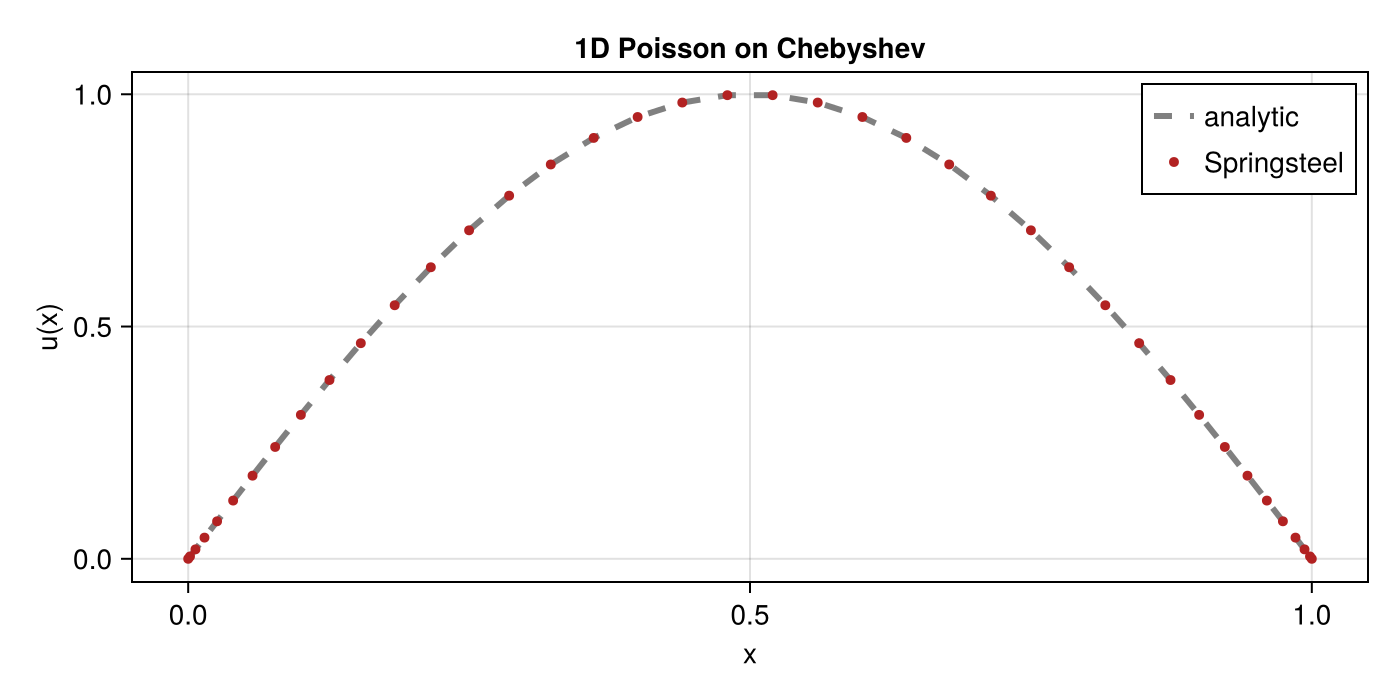

In [3]:
# ── Example 1 visualization ──────────────────────────────────────────────────
fig1 = Figure(size = (700, 350))
ax1  = Axis(fig1[1, 1]; title = "1D Poisson on Chebyshev", xlabel = "x", ylabel = "u(x)")
lines!(ax1, pts1, u_exact; label = "analytic", linewidth = 3, color = :gray, linestyle = :dash)
scatter!(ax1, pts1, u_num; label = "Springsteel", markersize = 7, color = :firebrick)
axislegend(ax1; position = :rt)
fig1


---
## Example 2 — Repeated solves reuse the cached factorisation

The stateful workspace is the point of the refactor: once `SpringsteelProblem`
is constructed, the factorisation, gammaBC fold, evaluation matrix, and scratch
buffers are all cached. Subsequent `solve!` calls with a different RHS skip
every rebuild and only pay for the backsolve itself.

Here we solve the same operator $u'' = f$ twice with two different right-hand
sides and confirm the factorisation object is identical across calls.


In [4]:
# ── Example 2: repeated solves ───────────────────────────────────────────────
N  = 30
gp2 = SpringsteelGridParameters(
    geometry = "Z",
    iMin = 0.0, iMax = 1.0, iDim = N, b_iDim = N,
    BCL = Dict("u" => Chebyshev.R1T0, "f" => Chebyshev.R0),
    BCR = Dict("u" => Chebyshev.R1T0, "f" => Chebyshev.R0),
    vars = Dict("u" => 1, "f" => 2))
grid2 = createGrid(gp2)
pts2  = solver_gridpoints(grid2, "u")

# First solve: f = -π² sin(π x)
grid2.physical[:, 2, 1] .= -π^2 .* sin.(π .* pts2)
u2   = Field(grid2, "u")
prob2 = SpringsteelProblem(grid2, ∂ᵢ^2 * u2 => :f)   # Symbol RHS pulls from grid
solve!(prob2)
F_first = prob2.workspace.factorization
u2_first = copy(grid2.physical[:, 1, 1])

# Second solve: same operator, different RHS.  No reconstruction.
grid2.physical[:, 2, 1] .= -(2π)^2 .* sin.(2π .* pts2)
solve!(prob2)
F_second = prob2.workspace.factorization
u2_second = copy(grid2.physical[:, 1, 1])

println("factorisation identical across solves : ", F_first === F_second)
println("1st solve  max err vs sin(π x)       : ", maximum(abs.(u2_first .- sin.(π .* pts2))))
println("2nd solve  max err vs sin(2π x)      : ", maximum(abs.(u2_second .- sin.(2π .* pts2))))


factorisation identical across solves : true
1st solve  max err vs sin(π x)       : 5.551115123125783e-16
2nd solve  max err vs sin(2π x)      : 1.1379786002407855e-15


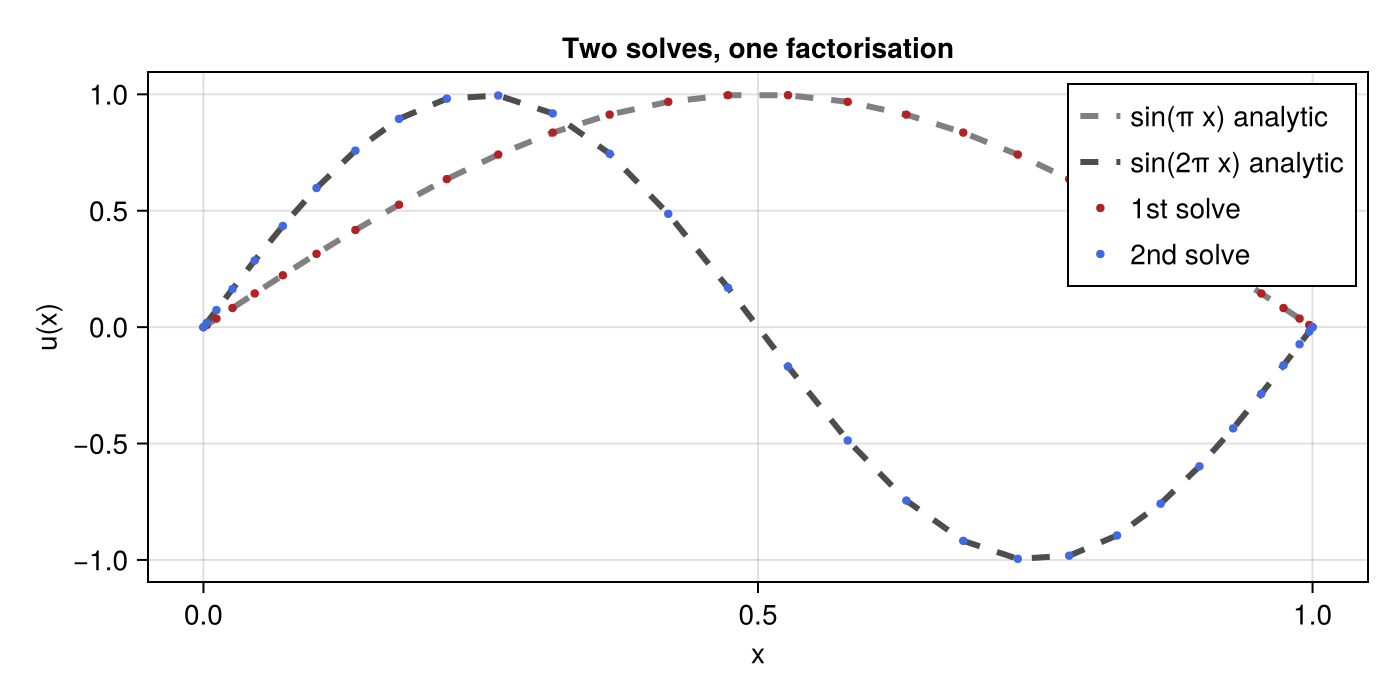

In [5]:
# ── Example 2 visualization ──────────────────────────────────────────────────
fig2 = Figure(size = (700, 350))
ax2  = Axis(fig2[1, 1]; title = "Two solves, one factorisation", xlabel = "x", ylabel = "u(x)")
lines!(ax2, pts2, sin.(π .* pts2);   label = "sin(π x) analytic",  color = :gray,   linestyle = :dash, linewidth = 3)
lines!(ax2, pts2, sin.(2π .* pts2);  label = "sin(2π x) analytic", color = :gray30, linestyle = :dash, linewidth = 3)
scatter!(ax2, pts2, u2_first;  label = "1st solve", color = :firebrick, markersize = 6)
scatter!(ax2, pts2, u2_second; label = "2nd solve", color = :royalblue, markersize = 6)
axislegend(ax2; position = :rt)
fig2


---
## Example 3 — 2D RZ Laplacian

Solve the 2D Laplacian $\nabla^2 u = f$ on an `RZ` grid (CubicBSpline in $x$,
Chebyshev in $z$) with a manufactured solution $u(x, z) = \sin(\pi x)\sin(\pi z)$,
so $f = -2\pi^2 u$.

The DSL supports both generic axis atoms (`∂ᵢ`, `∂ₖ`) and physical aliases
(`∂_x`, `∂_z`). On an `RZ` grid they are equivalent — `_lower` resolves physical
names to the generic axes at construction time based on the grid's geometry.

**Backend auto-pick**: RZ has a spline dimension, so `SpringsteelProblem` picks
`SparseLinearBackend` automatically (the `_default_backend` rule is "pure
Chebyshev → dense, anything else → sparse").


In [6]:
# ── Example 3: 2D RZ Laplacian ───────────────────────────────────────────────
gp3 = SpringsteelGridParameters(
    geometry = "RZ",
    iMin = 0.0, iMax = 1.0, num_cells = 20,
    kMin = 0.0, kMax = 1.0, kDim = 20, b_kDim = 20,
    BCL = Dict("u" => CubicBSpline.R1T0),
    BCR = Dict("u" => CubicBSpline.R1T0),
    BCB = Dict("u" => Chebyshev.R1T0),
    BCT = Dict("u" => Chebyshev.R1T0),
    vars = Dict("u" => 1))
grid3 = createGrid(gp3)

# Build the RHS from the manufactured solution
pts_mat = getGridpoints(grid3)                        # n_phys × 2 matrix
u_exact3 = [sin(π*p[1]) * sin(π*p[2]) for p in eachrow(pts_mat)]
f3       = -2π^2 .* u_exact3

u3    = Field(grid3, "u")
prob3 = SpringsteelProblem(grid3, (∂_x^2 + ∂_z^2) * u3 => f3)
solve!(prob3)

println("backend auto-picked   : ", typeof(prob3.backend))
println("max error vs analytic : ", maximum(abs.(grid3.physical[:, 1, 1] .- u_exact3)))


backend auto-picked   : SparseLinearBackend
max error vs analytic : 0.00018013839503786984


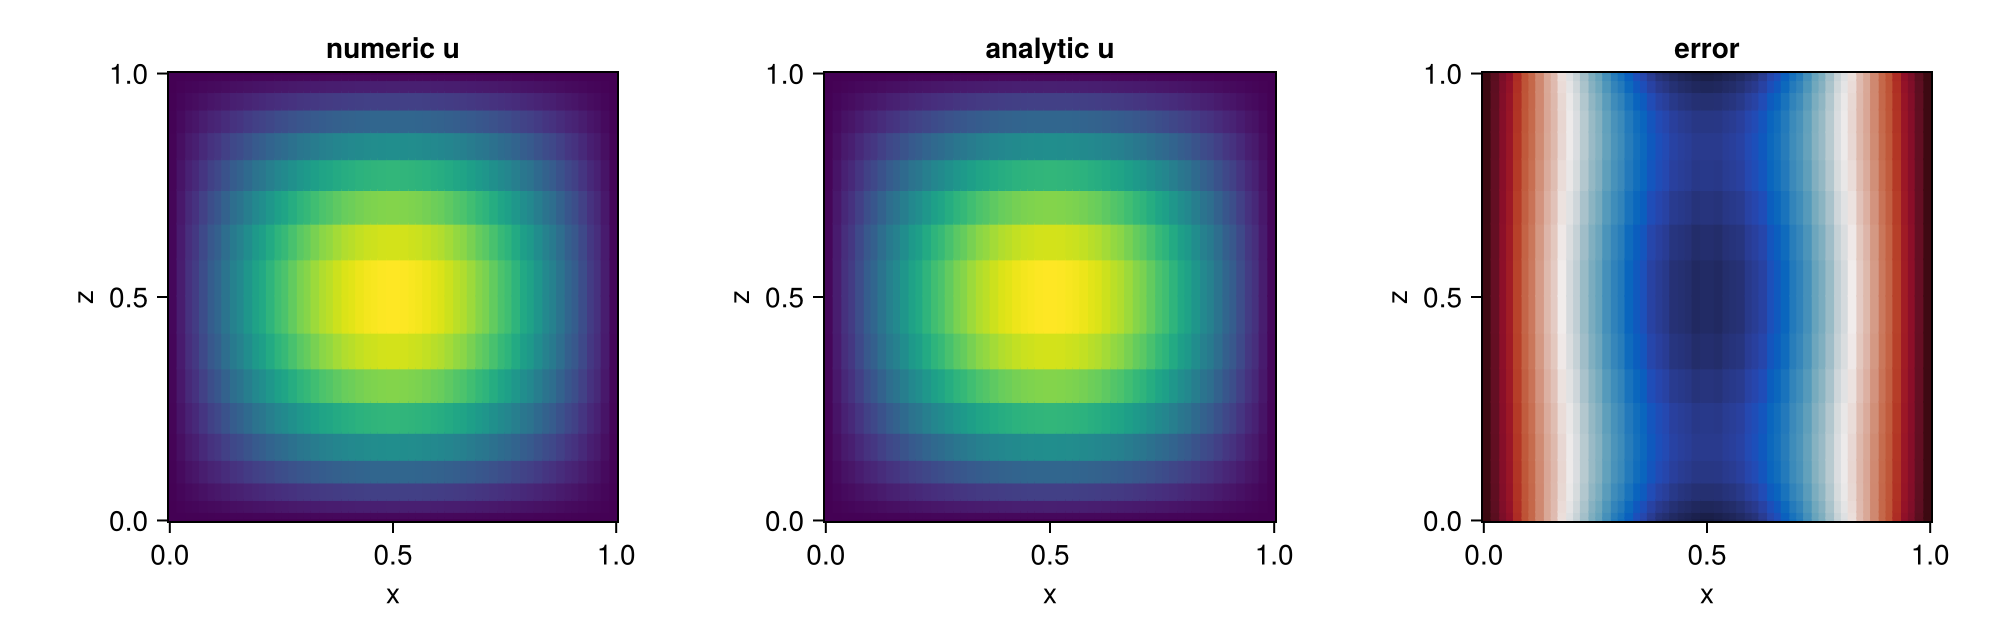

In [7]:
# ── Example 3 visualization: numeric vs analytic vs error ────────────────────
iDim3, kDim3 = gp3.iDim, gp3.kDim
U_num   = reshape(grid3.physical[:, 1, 1], (kDim3, iDim3))
U_exact = reshape(u_exact3,                 (kDim3, iDim3))
U_err   = U_num .- U_exact

xs = sort(unique(pts_mat[:, 1]))
zs = sort(unique(pts_mat[:, 2]))

fig3 = Figure(size = (1000, 320))
ax3a = Axis(fig3[1, 1]; title = "numeric u",  xlabel = "x", ylabel = "z", aspect = DataAspect())
ax3b = Axis(fig3[1, 2]; title = "analytic u", xlabel = "x", ylabel = "z", aspect = DataAspect())
ax3c = Axis(fig3[1, 3]; title = "error",      xlabel = "x", ylabel = "z", aspect = DataAspect())
heatmap!(ax3a, xs, zs, U_num';   colormap = :viridis)
heatmap!(ax3b, xs, zs, U_exact'; colormap = :viridis)
heatmap!(ax3c, xs, zs, U_err';   colormap = :balance)
fig3


---
## Example 4 — Variable coefficients (`Function` and `Symbol`)

The DSL accepts **four** coefficient forms on any derivative term:

| Form | When to use |
|---|---|
| `Float64` / `Int` | constant coefficient |
| `Vector{Float64}` | spatially varying, pre-computed |
| `Function` | spatially varying, evaluated at construction time on the grid's physical points (`f(x)` for 1D, `f(x, y, …)` for multi-D) |
| `Symbol` | spatially varying, snapshot of another grid variable (`grid.physical[:, var_idx, 1]`) |

Here we solve a 1D advection–diffusion problem

$$u''(x) + \alpha(x)\, u'(x) = f(x), \qquad \alpha(x) = \sin(x) + 2,$$

three different ways:
1. Pre-computing `α` as a `Vector{Float64}` (traditional)
2. Passing `α` as a `Function` (the DSL evaluates it for you)
3. Seeding `α` into a second grid variable and passing `:α` as a `Symbol`

All three must produce bit-identical solves.


In [8]:
# ── Example 4: variable coefficient — three equivalent forms ────────────────
gp4 = SpringsteelGridParameters(
    geometry = "R",
    iMin = 0.1, iMax = 1.0, num_cells = 40,
    BCL = Dict("u" => CubicBSpline.R1T0, "α" => CubicBSpline.R0),
    BCR = Dict("u" => CubicBSpline.R1T0, "α" => CubicBSpline.R0),
    vars = Dict("u" => 1, "α" => 2))

α_fn(x) = sin(x) + 2.0

grid_v = createGrid(gp4)
grid_f = createGrid(gp4)
grid_s = createGrid(gp4)

pts4  = solver_gridpoints(grid_v, "u")
α_vec = α_fn.(pts4)
grid_s.physical[:, 2, 1] .= α_vec      # seed α as a variable on grid_s

rhs = -(2π)^2 .* sin.(2π .* pts4)      # arbitrary RHS

u_v = Field(grid_v, "u")
u_f = Field(grid_f, "u")
u_s = Field(grid_s, "u")

prob_v = SpringsteelProblem(grid_v, (∂_x^2 + α_vec * ∂_x) * u_v => rhs)
prob_f = SpringsteelProblem(grid_f, (∂_x^2 + α_fn  * ∂_x) * u_f => rhs)
prob_s = SpringsteelProblem(grid_s, (∂_x^2 + :α    * ∂_x) * u_s => rhs)

solve!(prob_v); solve!(prob_f); solve!(prob_s)

u_v_num = grid_v.physical[:, 1, 1]
u_f_num = grid_f.physical[:, 1, 1]
u_s_num = grid_s.physical[:, 1, 1]

println("Vector vs Function  : ", maximum(abs.(u_v_num .- u_f_num)))
println("Vector vs Symbol    : ", maximum(abs.(u_v_num .- u_s_num)))


Vector vs Function  : 0.0
Vector vs Symbol    : 0.0


---
## Example 5 — Block multi-variable system

The block constructor accepts `Vector{Pair}`, one `Pair` per equation. Each LHS
can mix terms in **different** unknowns, and `SpringsteelProblem` builds and
factorises the assembled block operator.

We solve a manufactured coupled system on a 1D Chebyshev grid:

$$\begin{aligned}
u''(x) + v(x) &= f_u(x), \\
u(x) + v''(x) &= f_v(x),
\end{aligned}$$

with homogeneous Dirichlet BCs on both unknowns and manufactured solution
$u(x) = \sin(\pi x)$, $v(x) = \sin(2\pi x)$. This gives
$f_u = -\pi^2\sin(\pi x) + \sin(2\pi x)$ and
$f_v = \sin(\pi x) - 4\pi^2\sin(2\pi x)$.

Note that the DSL's `∂ᵢ^0` is the identity operator — any coefficient placed
on it lands on a zeroth-derivative term in the block cell.


In [9]:
# ── Example 5: 2-variable coupled block system ───────────────────────────────
N5 = 40
gp5 = SpringsteelGridParameters(
    geometry = "Z",
    iMin = 0.0, iMax = 1.0, iDim = N5, b_iDim = N5,
    BCL = Dict("u" => Chebyshev.R1T0, "v" => Chebyshev.R1T0,
               "fu" => Chebyshev.R0,  "fv" => Chebyshev.R0),
    BCR = Dict("u" => Chebyshev.R1T0, "v" => Chebyshev.R1T0,
               "fu" => Chebyshev.R0,  "fv" => Chebyshev.R0),
    vars = Dict("u" => 1, "v" => 2, "fu" => 3, "fv" => 4))
grid5 = createGrid(gp5)
pts5  = solver_gridpoints(grid5, "u")

# Seed manufactured RHSes into the grid, then resolve them via Symbol RHS
grid5.physical[:, 3, 1] .= -π^2 .* sin.(π .* pts5) .+ sin.(2π .* pts5)
grid5.physical[:, 4, 1] .= sin.(π .* pts5) .- (2π)^2 .* sin.(2π .* pts5)

u5 = Field(grid5, "u")
v5 = Field(grid5, "v")

eqs5 = [
    (∂ᵢ^2 * u5) + (∂ᵢ^0 * v5) => :fu,
    (∂ᵢ^0 * u5) + (∂ᵢ^2 * v5) => :fv,
]
prob5 = SpringsteelProblem(grid5, eqs5)
solve!(prob5)

u5_num = grid5.physical[:, 1, 1]
v5_num = grid5.physical[:, 2, 1]
println("u max err : ", maximum(abs.(u5_num .- sin.(π .* pts5))))
println("v max err : ", maximum(abs.(v5_num .- sin.(2π .* pts5))))


u max err : 6.661338147750939e-16
v max err : 1.9984014443252818e-15


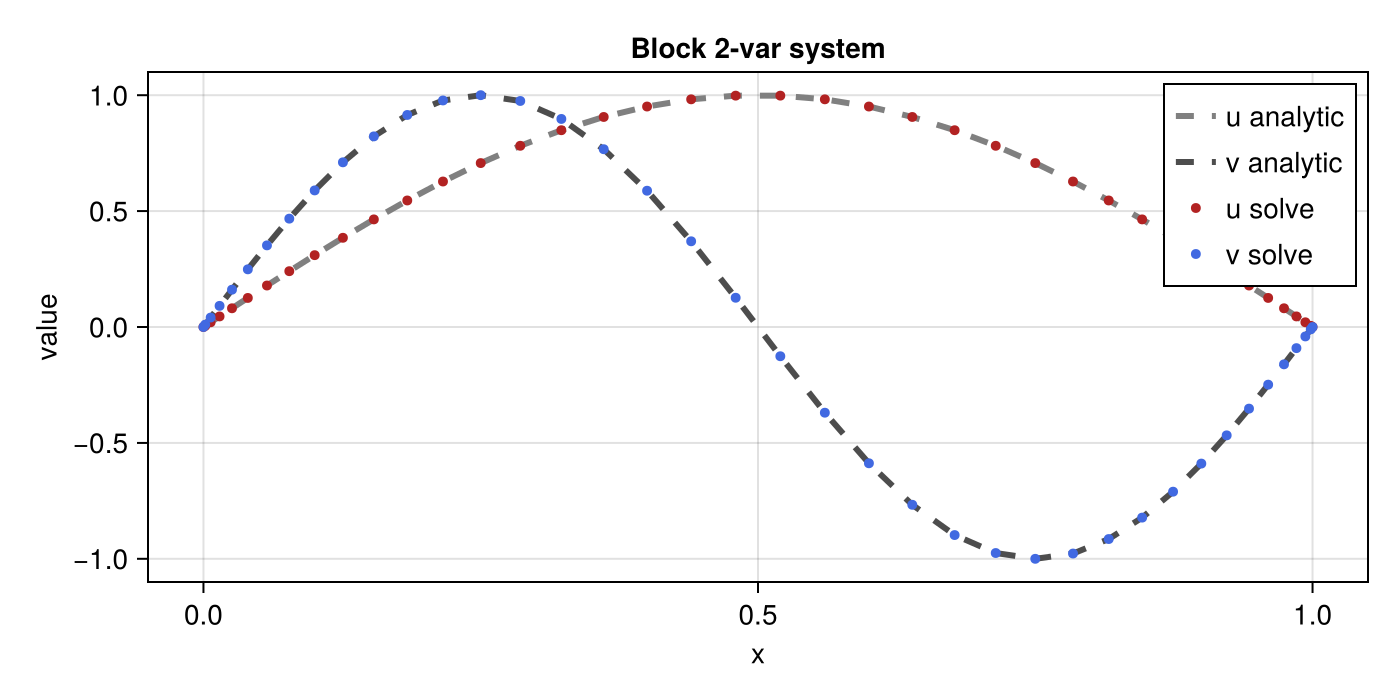

In [10]:
# ── Example 5 visualization ──────────────────────────────────────────────────
fig5 = Figure(size = (700, 350))
ax5  = Axis(fig5[1, 1]; title = "Block 2-var system", xlabel = "x", ylabel = "value")
lines!(ax5, pts5, sin.(π .* pts5);  label = "u analytic", color = :gray,   linestyle = :dash, linewidth = 3)
lines!(ax5, pts5, sin.(2π .* pts5); label = "v analytic", color = :gray30, linestyle = :dash, linewidth = 3)
scatter!(ax5, pts5, u5_num; label = "u solve", color = :firebrick, markersize = 7)
scatter!(ax5, pts5, v5_num; label = "v solve", color = :royalblue, markersize = 7)
axislegend(ax5; position = :rt)
fig5


---
## Example 6 — Backend selection and preconditioners

`SpringsteelProblem` takes a `backend=` kwarg accepting:
- `:auto` (default) — pure Chebyshev grids → `LocalLinearBackend` (dense LU);
  anything with a spline or Fourier dimension → `SparseLinearBackend` (sparse LU)
- `:dense` → `LocalLinearBackend`
- `:sparse` → `SparseLinearBackend`
- `:krylov` → `KrylovLinearBackend`, which uses `Krylov.gmres` (square) or
  `Krylov.lsmr` (rectangular) under the hood
- `:svd` → `SVDLinearBackend`, which factorises via `LinearAlgebra.svd` and
  solves through the SVD pseudo-inverse. Useful for rank-deficient or
  ill-conditioned operators and regularised least-squares; pass an explicit
  `SVDLinearBackend(rtol = ε)` to truncate singular values below `ε · σ_max`
  before the solve. Full dense SVD is O(N³), so it's the right choice for
  small-to-moderate systems where you want explicit control over the
  singular spectrum.
- an explicit backend instance with configuration baked in, e.g.
  `KrylovLinearBackend(preconditioner)` or `SVDLinearBackend(rtol = 1e-8)`

For Krylov you can also pass `preconditioner=` at the constructor level:
- `nothing` / `:default` → no preconditioner (default)
- `:diag` → build `Diagonal(1 ./ diag(A))` from the assembled operator
  (explicit opt-in — it isn't the default because BC-augmented systems
  have row magnitudes spanning O(1) at boundaries to O(N²) in the interior)
- any `AbstractMatrix` or callable → passed through to Krylov as the `M=` kwarg

Here we solve the same 1D Chebyshev Poisson problem with all four backends and
confirm the answers agree. For this size Chebyshev grid the auto-pick is dense.


In [11]:
# ── Example 6: four backends on the same problem ───────────────────────────
N6 = 25
gp6 = SpringsteelGridParameters(
    geometry = "Z",
    iMin = 0.0, iMax = 1.0, iDim = N6, b_iDim = N6,
    BCL = Dict("u" => Chebyshev.R1T0),
    BCR = Dict("u" => Chebyshev.R1T0),
    vars = Dict("u" => 1))

f6(grid) = begin
    p = solver_gridpoints(grid, "u")
    -π^2 .* sin.(π .* p)
end

grid_d = createGrid(gp6); pts6 = solver_gridpoints(grid_d, "u")
grid_s = createGrid(gp6)
grid_k = createGrid(gp6)
grid_v = createGrid(gp6)

prob_d = SpringsteelProblem(grid_d, ∂ᵢ^2 * Field(grid_d, "u") => f6(grid_d); backend = :dense)
prob_s = SpringsteelProblem(grid_s, ∂ᵢ^2 * Field(grid_s, "u") => f6(grid_s); backend = :sparse)
prob_k = SpringsteelProblem(grid_k, ∂ᵢ^2 * Field(grid_k, "u") => f6(grid_k); backend = :krylov)
prob_v = SpringsteelProblem(grid_v, ∂ᵢ^2 * Field(grid_v, "u") => f6(grid_v); backend = :svd)

solve!(prob_d); solve!(prob_s); solve!(prob_k); solve!(prob_v)

u_d = grid_d.physical[:, 1, 1]
u_s = grid_s.physical[:, 1, 1]
u_k = grid_k.physical[:, 1, 1]
u_v = grid_v.physical[:, 1, 1]
u_ex6 = sin.(π .* pts6)

println("dense   max err : ", maximum(abs.(u_d .- u_ex6)))
println("sparse  max err : ", maximum(abs.(u_s .- u_ex6)))
println("krylov  max err : ", maximum(abs.(u_k .- u_ex6)))
println("svd     max err : ", maximum(abs.(u_v .- u_ex6)))
println()
println("dense  vs sparse : ", maximum(abs.(u_d .- u_s)))
println("dense  vs krylov : ", maximum(abs.(u_d .- u_k)))
println("dense  vs svd    : ", maximum(abs.(u_d .- u_v)))


dense   max err : 4.440892098500626e-16
sparse  max err : 3.3306690738754696e-16
krylov  max err : 4.0365038761489957e-13
svd     max err : 3.4083846855992306e-14

dense  vs sparse : 5.551115123125783e-16
dense  vs krylov : 4.0365958448987494e-13
dense  vs svd    : 3.419486915845482e-14


---
## Where to go next

- **Legacy kwarg-form API** is still in the codebase for backward compatibility.
  See `SpringsteelProblem(grid; operator=L, rhs=f)` and `assemble_from_equation`;
  both rebuild the workspace from scratch on every `solve()` call, so they're
  fine for one-shot problems but leave performance on the table for iterated
  solves. The docstrings on both point at the new Pair-based form.
- **Nonlinear / optimisation problems** still use the `OptimizationBackend` via
  the `SpringsteelOptimizationExt` package extension — load `Optimization.jl` to
  activate it.
- **Coefficient resolution** is a snapshot at construction time. If you mutate
  `grid.physical[:, α_idx, 1]` after constructing a problem, the cached
  coefficient doesn't update. For live coefficient updates, rebuild the problem
  or pre-compute a `Vector{Float64}` you update in place.
- **Matrix-free iterative solves** for very large problems (the canonical RR
  nc=100 case) are a deferred follow-up and will be implemented in a future release. The current `:krylov` backend still assembles the sparse operator.
